# Generative Adversarial Network (GAN) training notebook

In this notebook, the degradated data is loaded from drive, then it's used to train a GAN model.  
It's meant to be executed **after** `0.Data_Degradation.ipynb` and the dataset is saved on Drive.  
It's weights will be saved in the folder `../weights/`, which will be used for the comparison in the final notebook.  

## Libraries & Drive Access & some constants

In [28]:
from __future__ import annotations

import json
import shutil
from pathlib import Path
from dataclasses import dataclass
from typing import Literal

import numpy as np
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset as TorchDataset
from datasets import load_from_disk, DatasetDict

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = Path("/content/drive/MyDrive/Computational Imaging")
DRIVE_DATASET_DIR = BASE_DIR / "dataset"
LOCAL_DATASET_DIR = Path("/content/dataset")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Loading the dataset from drive

Loads the degradated dataset generated from `0.Data_Degradation.ipynb` and saved on Drive in the folder `Computational Imaging/dataset` as a `DatasetDict` with columns: `x` (clean), `y_005`/`y_010`/`y_050`/`y_100` (blur + gaussian noise with σ=0.005/0.01/0.05/0.1) and `label` (name of the class of x).  

This dataset will be incapsulated in a PyTorch `DataLoader`, ready for training the GAN model.  

#### Config

In [29]:
# y_<key> columns made in 0_Data_Degradation.ipynb (key = sigma * 1000)
NOISE_LEVEL_KEYS: tuple[str, ...] = ("005", "010", "050", "100")
NOISE_LEVEL_TO_SIGMA: dict[str, float] = {"005": 0.005, "010": 0.01, "050": 0.05, "100": 0.1}


@dataclass(frozen=True)
class DataConfig:
  noise_level: Literal["005", "010", "050", "100", "all"] = "050"
  # value range of the image, depends on the activation function that will be used
  #   zero_one = ReLU
  #   minus_one_one = Tanh
  image_range: Literal["zero_one", "minus_one_one"] = "minus_one_one"
  # numbers of grouped images
  batch_size: int = 32

  def __post_init__(self):
    """
    In case user sets wrong noise_level
    """
    valid = set(NOISE_LEVEL_KEYS) | {"all"}
    if self.noise_level not in valid:
      raise ValueError(f"noise_level need to be {valid}, got {self.noise_level!r}")


#### Copy dataset from Drive locally

In [30]:
def copy_dataset_locally(drive_dir: Path = DRIVE_DATASET_DIR, local_dir: Path = LOCAL_DATASET_DIR) -> Path:
  """
  Copy the dataset from Drive to the local disk of Colab, so it's faster to later run the GAN

  Parameters: 
    drive_dir: the path where the dataset is stored in the Drive
    local_dir: the path where the dataset will be saved in the colab temp folder
  """
  if not drive_dir.exists():
    raise FileNotFoundError(
        f"{drive_dir} drive folder not found. Please run '0_Data_Degradation.ipynb' before and check that it has saved the dataset "
    )

  # avoid to copy again the dataset is the folder is already there
  if local_dir.exists():
    print(f"Copy already exists in {local_dir}")
    return local_dir


  print(f"Start of copying {drive_dir} -> {local_dir}")
  shutil.copytree(drive_dir, local_dir)
  print("End of copying")
  return local_dir

#### Creating Dataset & Dataloader

In [31]:
class DeblurDataset(TorchDataset):
  """
  Single split of the dataset(train, validation, test), with all having the same config
  """

  def __init__(self, ds_split, config: DataConfig):
    self.ds_split = ds_split
    self.config = config
    self.noise_keys = list(NOISE_LEVEL_KEYS) if config.noise_level == "all" else [config.noise_level]
    self.to_tensor = T.ToTensor() # convert PIL uint8 [0, 255] to float [0, 1], C x H x W

  def __len__(self) -> int:
    """
    If config.noise_level == "all", then each clean image is bounded to each of the 4 level of noise, which means len(dataset) == 4 * len(ds_split)
    """
    return len(self.ds_split) * len(self.noise_keys)

  def _scale(self, t: torch.Tensor) -> torch.Tensor:
    """
    Maps values from [0,1] to [-1,1] = ReLU to Tanh
    """
    return t * 2.0 - 1.0 if self.config.image_range == "minus_one_one" else t

  def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor, int, str]:
    """
    Returns:
      degraded: y_<sigma>, FloatTensor [3, 256, 256], input of the generator
      clean: x, FloatTensor [3, 256, 256], ground truth, objective of GAN
      label: int, class of ImageNet
      noise_key: string, the value of the noise of the degraded image
    """
    sample_idx, noise_idx = divmod(idx, len(self.noise_keys))
    row = self.ds_split[sample_idx]
    noise_key = self.noise_keys[noise_idx]
    clean_pil = row["x"]

    clean = self._scale(self.to_tensor(clean_pil))
    degraded = self._scale(self.to_tensor(row[f"y_{noise_key}"]))

    return degraded, clean, row["label"], noise_key


def setup_dataloaders(config: DataConfig = DataConfig()) -> tuple[DataLoader, DataLoader, DataLoader, dict[int, str]]:
  """
    Parameters:
      config: config parameters
    
    Returns:
      train_loader: contains the train images
      val_loader: contains the validation images
      test_loader: contains the test images
      id2label: dict of correlation class number - class name
  """
  local_path = copy_dataset_locally()
  ds_dict: DatasetDict = load_from_disk(str(local_path))


  # open and get the names of the labels of the used class of the original dataset
  id2label: dict[int, str] = {}
  labels_path = local_path / "labels.json"
  if labels_path.exists():
    with open(labels_path) as f:
      id2label = {int(k): v for k, v in json.load(f).items()}

  #create the train_loader, validation_loader and test_loader
  loaders = []
  for split, shuffle in (("train", True), ("validation", False), ("test", False)):
    dataset_readytogo = DeblurDataset(ds_dict[split], config)
    loaders.append(DataLoader(dataset_readytogo, batch_size=config.batch_size, shuffle=shuffle, num_workers=2,drop_last=shuffle))

  return (*loaders, id2label)

In [32]:
data_config = DataConfig(noise_level="all") 
train_loader, val_loader, test_loader, id2label = setup_dataloaders(data_config)

Copy already exists in /content/dataset


#### Sanity Check

batch train/val/test: 520 / 65 / 65 (with batch size of 32)
degraded: (32, 3, 256, 256), range [-1.000, 1.000]
clean:    (32, 3, 256, 256), range [-1.000, 1.000]


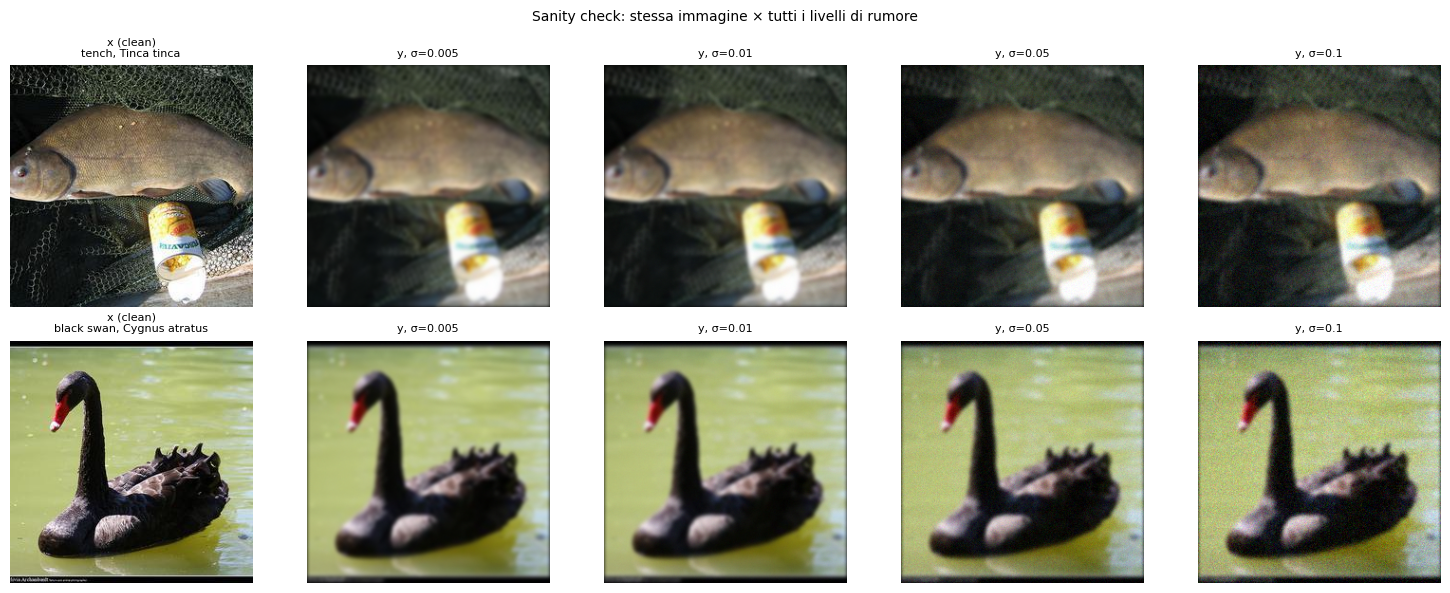

In [ ]:
print(f"batch train/val/test: {len(train_loader)} / {len(val_loader)} / {len(test_loader)} (with batch size of {data_config.batch_size})")

degraded_b, clean_b, label_b, noise_keys_b = next(iter(train_loader))
print(f"degraded: {tuple(degraded_b.shape)}, range [{degraded_b.min():.3f}, {degraded_b.max():.3f}]")
print(f"clean:    {tuple(clean_b.shape)}, range [{clean_b.min():.3f}, {clean_b.max():.3f}]")


def to_img(t: torch.Tensor) -> np.ndarray:
    if data_config.image_range == "minus_one_one":
        t = (t + 1) / 2
    return t.permute(1, 2, 0).clamp(0, 1).cpu().numpy()

# get 2 specific images, and show each type of noise
# i use the DeblurDataset direcly as to avoid shiffle, and it's deterministic
_inner_ds = train_loader.dataset
_n_noise = len(data_config.noise_level == "all" and NOISE_LEVEL_KEYS or [data_config.noise_level])
_noise_keys = list(NOISE_LEVEL_KEYS) if data_config.noise_level == "all" else [data_config.noise_level]
N_SHOW_IMAGES = 2
n_cols = len(_noise_keys) + 1  # +1 for clean img

fig, axes = plt.subplots(N_SHOW_IMAGES, n_cols, figsize=(3 * n_cols, 3 * N_SHOW_IMAGES))
if N_SHOW_IMAGES == 1:
    axes = axes[np.newaxis, :]

for row_i in range(N_SHOW_IMAGES):
    # clean (stessa per tutti i noise level)
    flat_idx_clean = row_i * len(_noise_keys)  # punta al primo noise di questa immagine
    _, clean_img, label_id, _ = _inner_ds[flat_idx_clean]

    ax = axes[row_i, 0]
    ax.imshow(to_img(clean_img))
    ax.set_title(f"x (clean)\n{id2label.get(label_id, label_id)}", fontsize=8)
    ax.axis("off")

    for col_i, nk in enumerate(_noise_keys):
        flat_idx = row_i * len(_noise_keys) + col_i
        deg_img, _, _, returned_nk = _inner_ds[flat_idx]
        sigma = NOISE_LEVEL_TO_SIGMA[returned_nk]

        ax = axes[row_i, col_i + 1]
        ax.imshow(to_img(deg_img))
        ax.set_title(f"y, σ={sigma}", fontsize=8)
        ax.axis("off")

plt.suptitle("Sanity check: stessa immagine × tutti i livelli di rumore", fontsize=10)
plt.tight_layout()
plt.show()